# Stage 2 XGBoost — Health Outcome Prediction

 
**Targets:** `target_anc_gap`, `target_unmet_fp`  
**Depends on:** `07_data_integration.ipynb`, `08_clustering.ipynb` (or `scripts/run_stage2_data_prep.py`)

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.stage2_xgboost import (
    configure_logging,
    load_stage2_data,
    train_all_stage2_xgboost,
    TARGET_DISPLAY,
)

configure_logging()

In [2]:
# Ensure Stage 2 inputs exist (run once if missing)
stage2_files = [
    PROJECT_ROOT / 'data/processed/stage2/X_stage2_preclustering.csv',
    PROJECT_ROOT / 'data/processed/stage2/y_stage2_targets.csv',
    PROJECT_ROOT / 'outputs/stage2_results/cluster_assignments.csv',
]
if not all(p.exists() for p in stage2_files):
    print('Stage 2 inputs missing — running data prep script...')
    %run ../scripts/run_stage2_data_prep.py
else:
    print('Stage 2 inputs found.')

Stage 2 inputs found.


In [3]:
X_full, y = load_stage2_data()
print(f'Feature matrix: {X_full.shape}')
for col in y.columns:
    nn = y[col].notna().sum()
    print(f'{col}: non-null N = {nn:,}')

2026-07-22 19:42:43,067 | INFO | src.models.stage2_xgboost | Loaded Stage 2 data: X=(724115, 43), targets=['target_unmet_fp', 'target_anc_gap']


Feature matrix: (724115, 43)
target_unmet_fp: non-null N = 466,859
target_anc_gap: non-null N = 0


In [4]:
# Train XGBoost for all available targets
bundle = train_all_stage2_xgboost()
metrics_df = bundle.get('metrics_df')
metrics_df

2026-07-22 19:42:50,215 | INFO | src.models.stage2_xgboost | Loaded Stage 2 data: X=(724115, 43), targets=['target_unmet_fp', 'target_anc_gap']
2026-07-22 19:42:50,284 | WARNING | src.models.stage2_xgboost | Skipping target_anc_gap: No non-null rows for target_anc_gap. If target_anc_gap, ensure m14 is present in the raw extract.
2026-07-22 19:42:51,014 | INFO | src.models.stage2_xgboost | target_unmet_fp — analytic sample: 466859 rows (positive rate 0.1064)
2026-07-22 19:42:53,647 | INFO | src.models.stage2_xgboost | Hyperparameter tuning on 80,000-row stratified subsample
2026-07-22 19:43:57,027 | INFO | src.models.stage2_xgboost | Best hyperparameters: {'max_depth': 5, 'n_estimators': 300} (CV ROC-AUC=0.6501)
2026-07-22 19:43:57,206 | INFO | src.models.stage2_xgboost | Training Stage 2 XGBoost for target_unmet_fp ...
2026-07-22 19:44:09,117 | INFO | src.models.stage2_xgboost | Saved model -> C:\major project\BarrierLens_MP_G25_P48\saved_models\stage2\stage2_xgboost_target_unmet_fp.pk


=== XGBoost | target_unmet_fp ===
  Accuracy    : 0.5927
  ROC-AUC     : 0.668
  Precision   : 0.1603
  Recall      : 0.6675
  F1-Score    : 0.2586
  CV_ROC-AUC  : 0.6652
              precision    recall  f1-score   support

           0       0.94      0.58      0.72     83438
           1       0.16      0.67      0.26      9934

    accuracy                           0.59     93372
   macro avg       0.55      0.63      0.49     93372
weighted avg       0.85      0.59      0.67     93372

target_unmet_fp: socioeconomic-only=0.6683 | +barriers=0.6662 | uplift=-0.0022


2026-07-22 19:46:01,275 | INFO | src.models.stage2_xgboost | SHAP plots saved to C:\major project\BarrierLens_MP_G25_P48\outputs\stage2_results\shap
2026-07-22 19:46:01,385 | INFO | src.models.stage2_xgboost | Saved evaluation metrics -> C:\major project\BarrierLens_MP_G25_P48\outputs\stage2_results\xgboost_evaluation_results.csv


,Model,Target,Accuracy,ROC-AUC,Precision,Recall,F1-Score,TrainSize,TestSize,PositiveRate,param_max_depth,param_n_estimators,CV_ROC-AUC,Baseline_ROC-AUC,Full_ROC-AUC,Barrier_Uplift
0,XGBoost,target_unmet_fp,0.5927,0.668,0.1603,0.6675,0.2586,373487,93372,0.1064,5,300,0.6652,0.6683,0.6662,-0.0022


In [5]:
# Barrier uplift summary
if metrics_df is not None:
    display(metrics_df[['Target', 'Baseline_ROC-AUC', 'Full_ROC-AUC', 'Barrier_Uplift']])

,Target,Baseline_ROC-AUC,Full_ROC-AUC,Barrier_Uplift
0,target_unmet_fp,0.6683,0.6662,-0.0022


In [6]:
# Top SHAP features per target
import pandas as pd
shap_dir = PROJECT_ROOT / 'outputs/stage2_results/shap'
for target, tb in bundle.get('targets', {}).items():
    print(f"\n=== Top SHAP features: {TARGET_DISPLAY.get(target, target)} ===")
    print(tb['shap_importance'].head(15).to_string(index=False))


=== Top SHAP features: Unmet Family Planning Need ===
                feature  mean_abs_shap
                   v012       0.319499
                   v013       0.110055
             v130_hindu       0.109446
           v501_married       0.109031
                   v106       0.102637
   media_exposure_index       0.093085
 household_barrier_prob       0.068188
               v481_yes       0.062739
composite_barrier_score       0.062727
  logistic_barrier_prob       0.055320
  facility_barrier_prob       0.046518
                   v190       0.040669
    vulnerability_score       0.033711
           v501_widowed       0.030409
             v131_tribe       0.029491


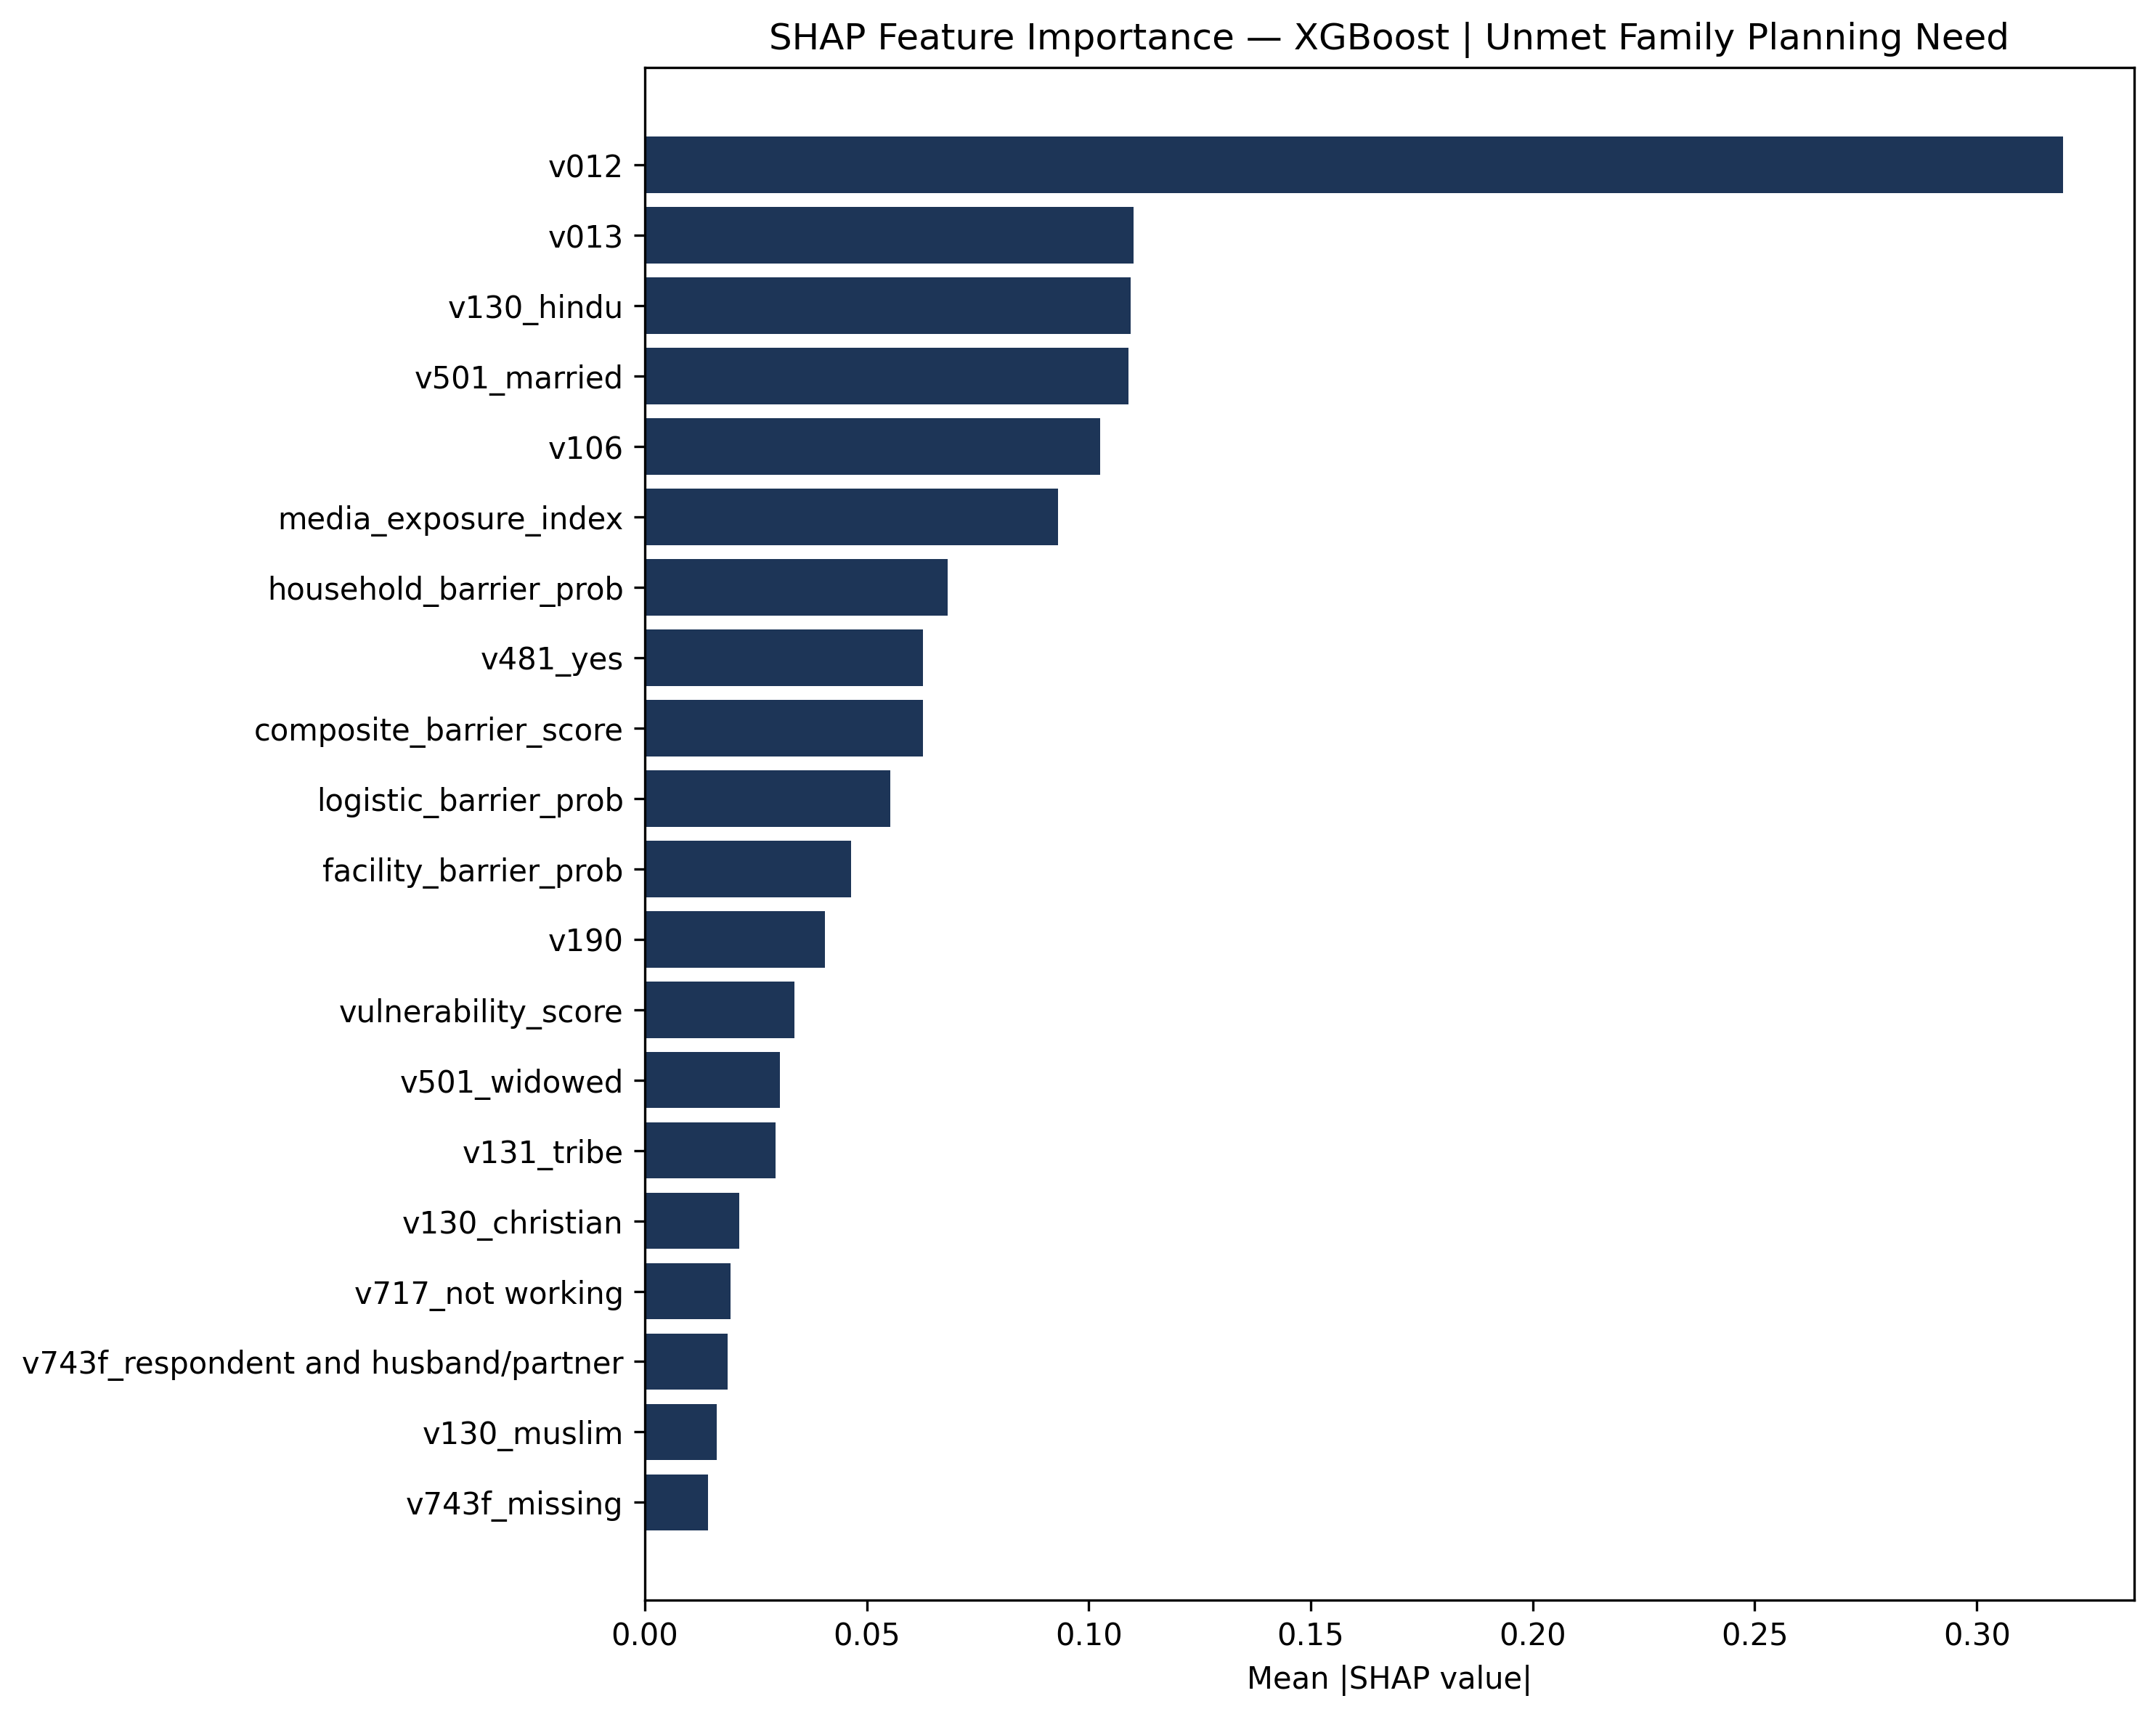

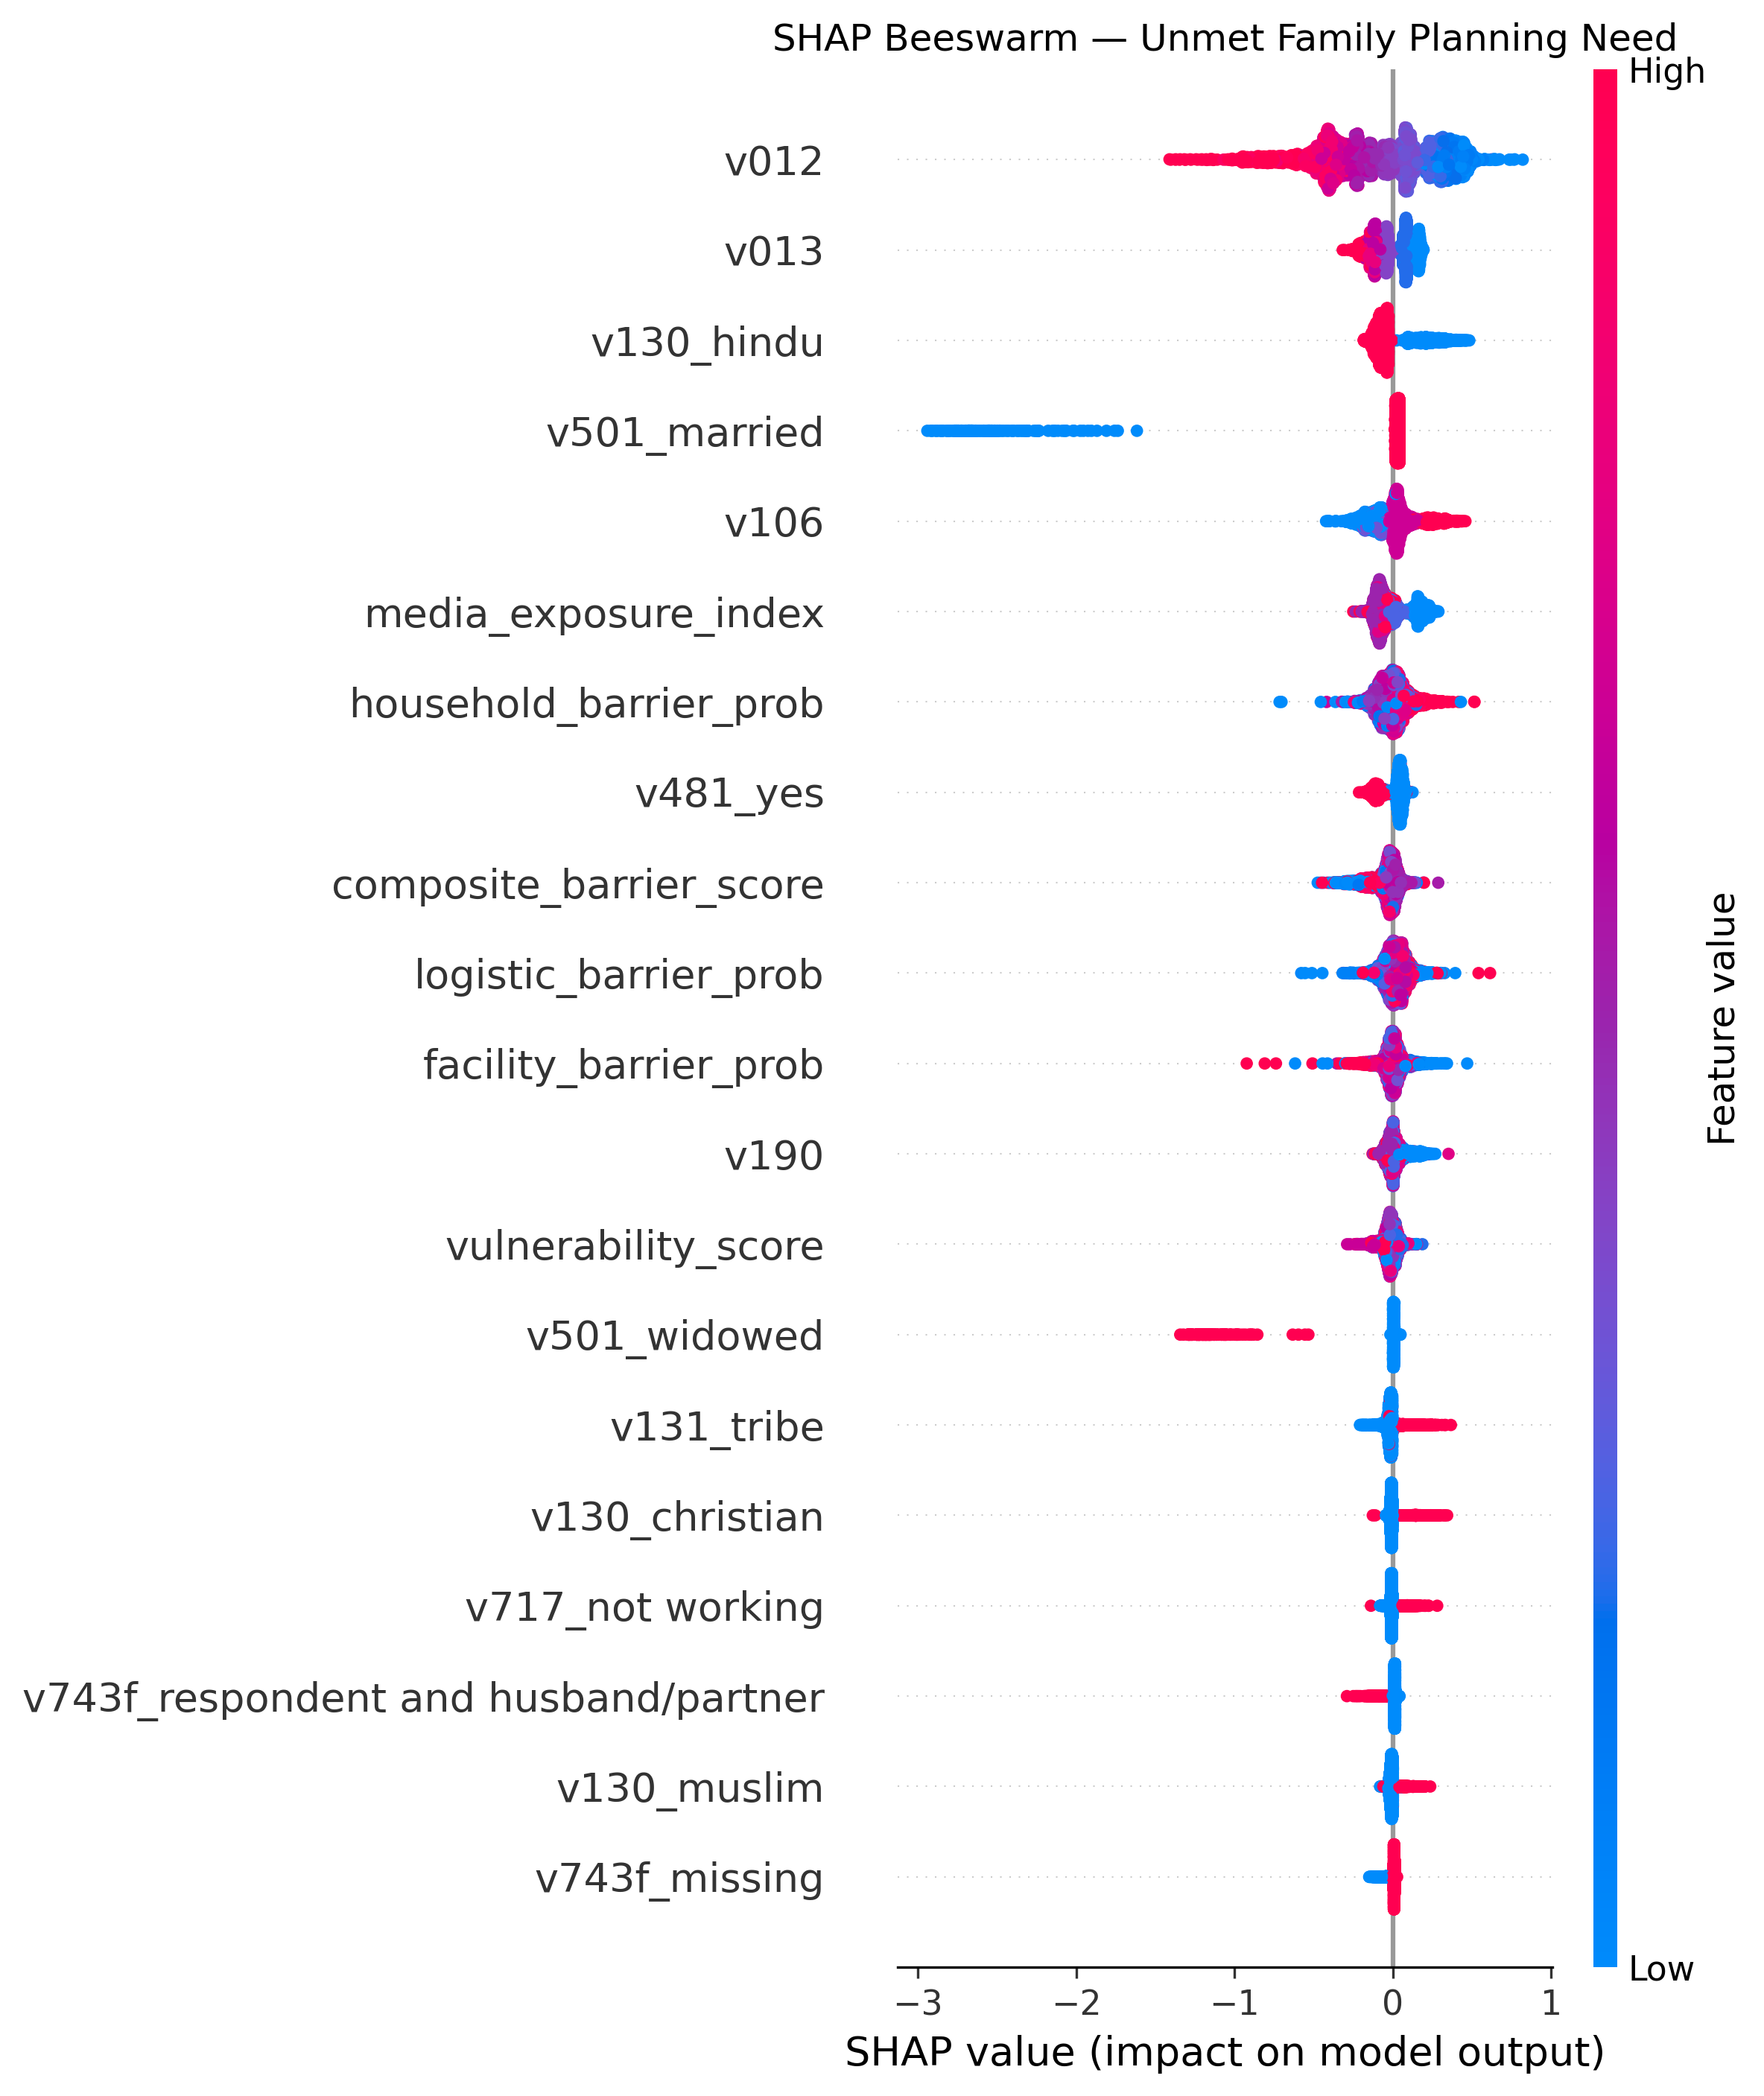

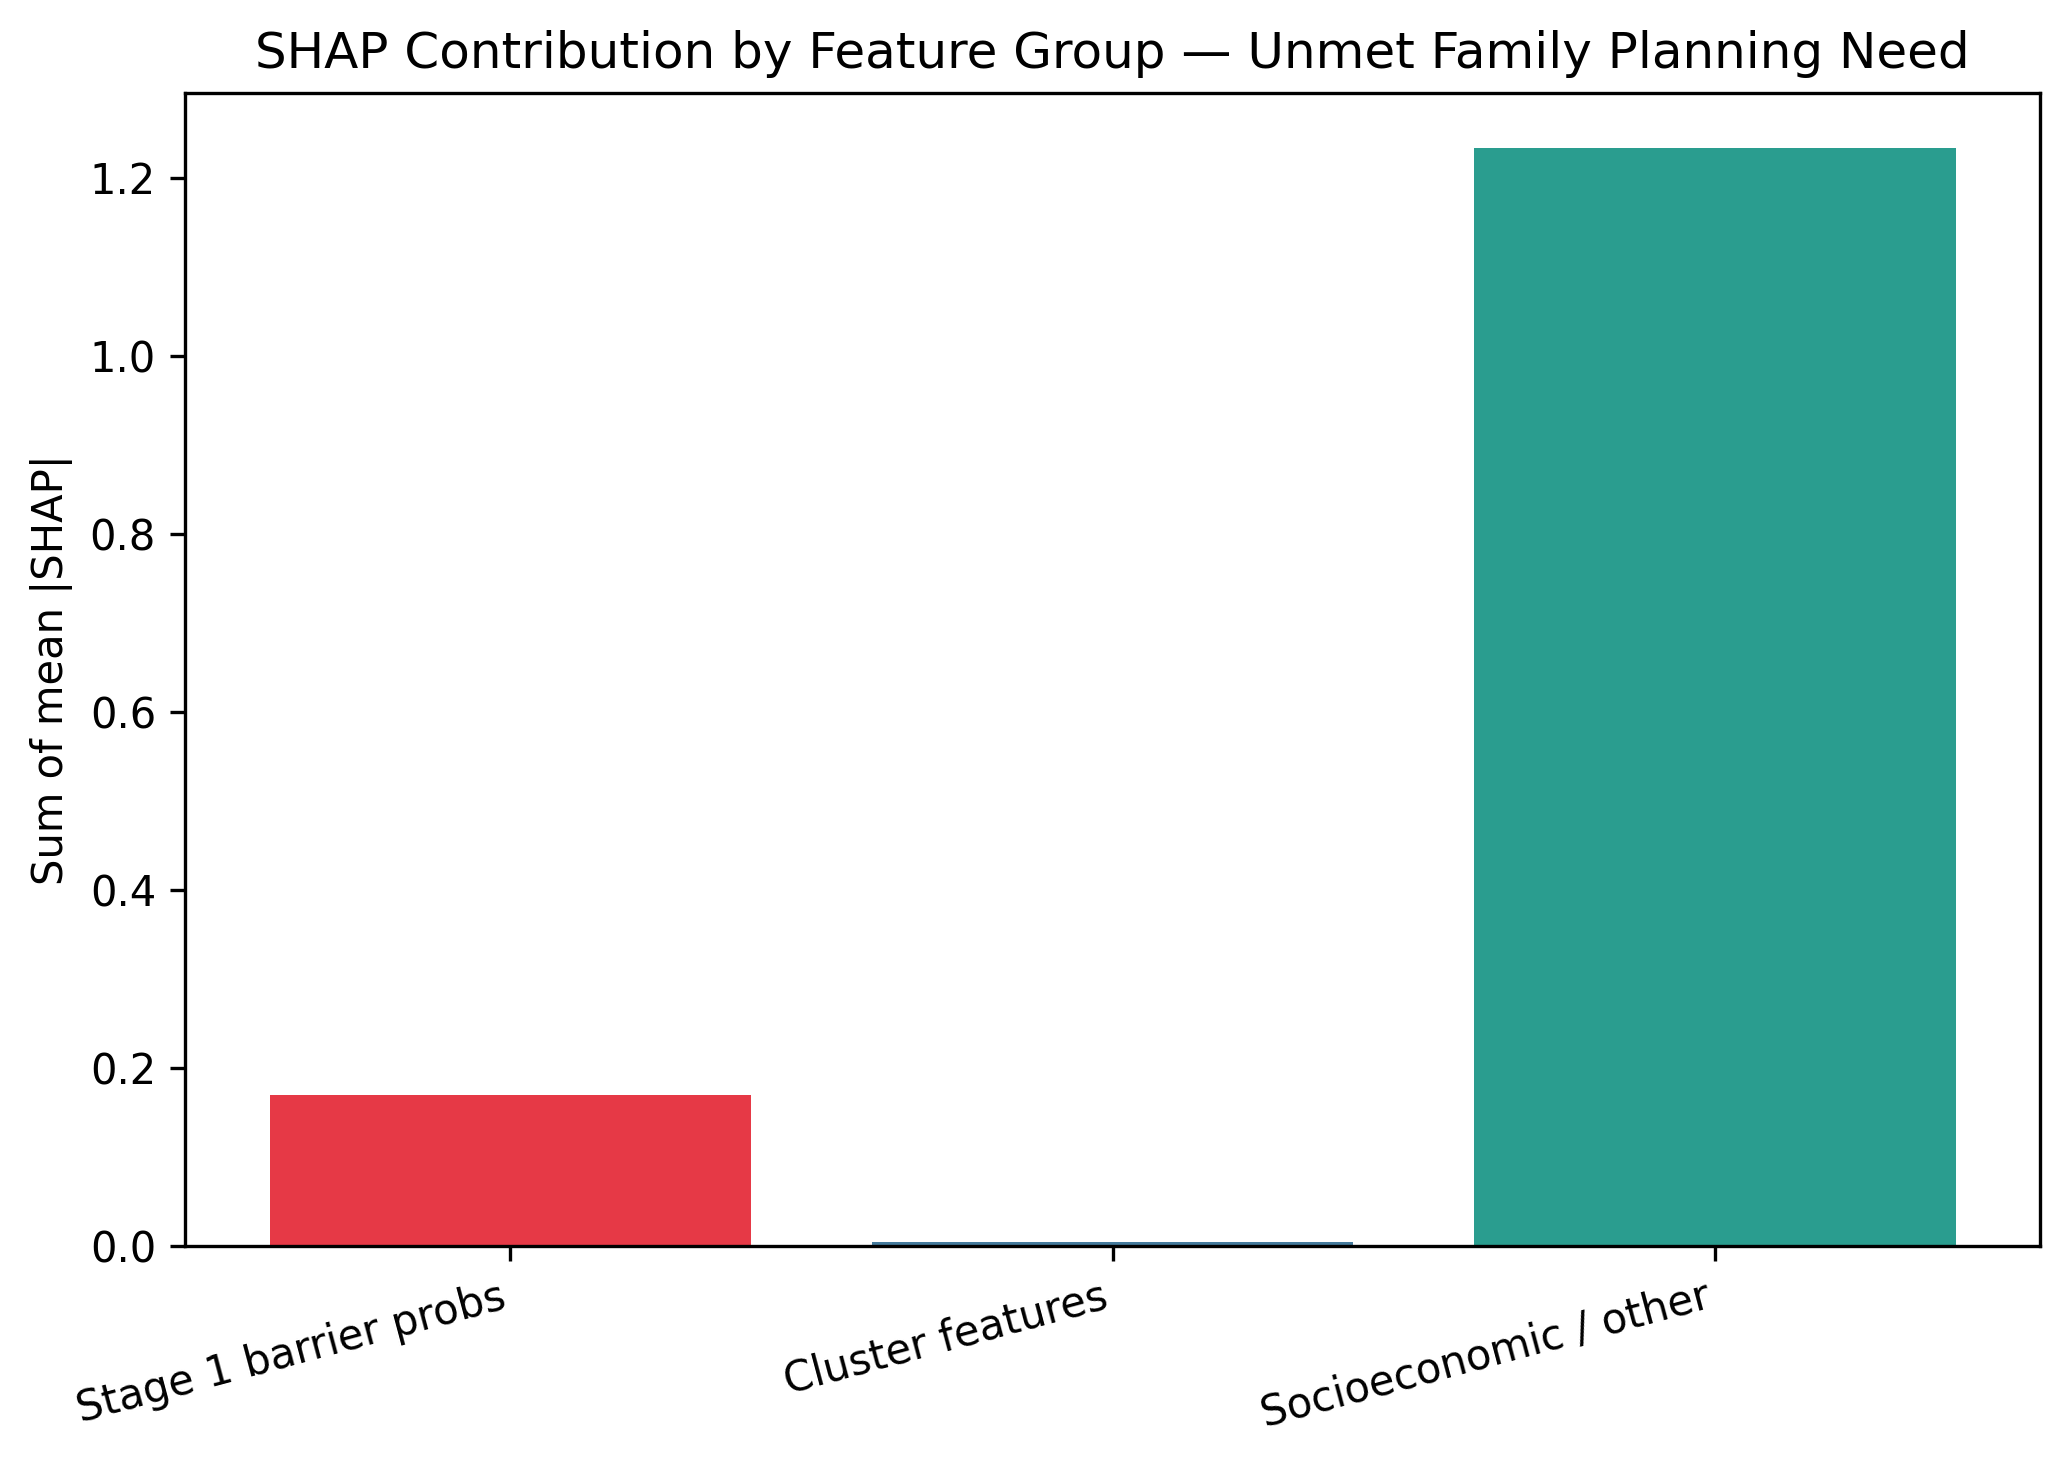

In [7]:
from IPython.display import Image, display
for target in bundle.get('targets', {}):
    for kind in ['bar', 'beeswarm', 'group_comparison']:
        path = shap_dir / f'xgb_shap_{kind}_{target}.png'
        if path.exists():
            display(Image(filename=str(path)))